## Data Import and Discovery

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor



DATA = 'dataset'

orders = pd.read_csv(f'{DATA}/train.csv')
centres = pd.read_csv(f'{DATA}/fulfilment_center_info.csv')
meals = pd.read_csv(f'{DATA}/meal_info.csv')

print('orders:',orders.shape)
orders.head()


orders: (456548, 9)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [2]:
print('orders:',orders.columns)

orders: Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders'],
      dtype='object')


In [3]:
print('orders:',orders.dtypes)

orders: id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
dtype: object


In [4]:
print('centres:',centres.columns)

centres: Index(['center_id', 'city_code', 'region_code', 'center_type', 'op_area'], dtype='object')


In [5]:
print('centres:',centres.dtypes)

centres: center_id        int64
city_code        int64
region_code      int64
center_type     object
op_area        float64
dtype: object


In [6]:
print('meals:',meals.columns)

meals: Index(['meal_id', 'category', 'cuisine'], dtype='object')


In [7]:
print('meals:',meals.dtypes)

meals: meal_id      int64
category    object
cuisine     object
dtype: object


In [8]:
#check for duplicates
orders.duplicated(['center_id','meal_id','week']).sum()

np.int64(0)

In [9]:

orders['num_orders'].describe()


count    456548.000000
mean        261.872760
std         395.922798
min          13.000000
25%          54.000000
50%         136.000000
75%         324.000000
max       24299.000000
Name: num_orders, dtype: float64

In [10]:
# join three tables using left join

df = orders.merge(centres, on='center_id', how='left').merge(meals, on='meal_id', how='left')
print(df.shape)
df.head()

(456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


<Axes: ylabel='Frequency'>

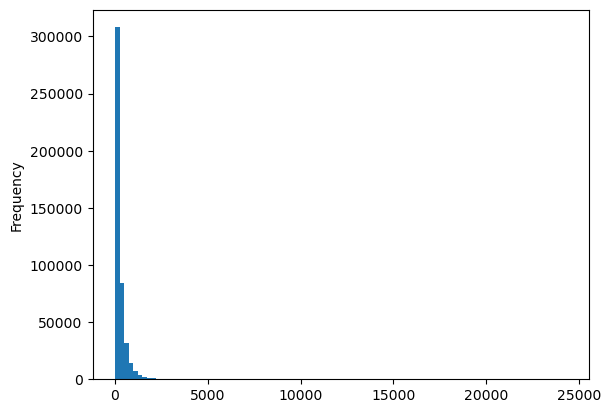

In [11]:
df['num_orders'].plot(kind='hist', bins=100)

np.log1p(df['num_orders']).plot(kind='hist', bins=100)


<Axes: >

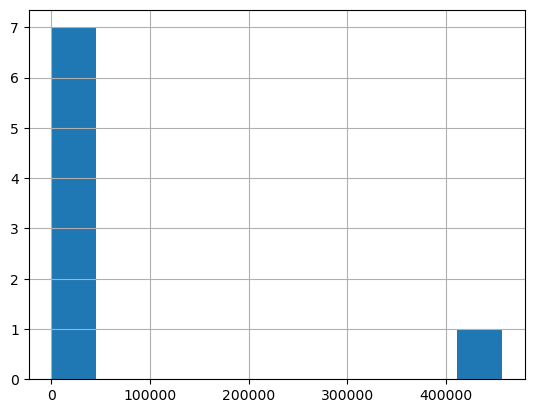

In [12]:
# right skewed data
orders['num_orders'].describe().hist()


In [13]:
# check for missing values

orders.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

In [14]:
# check for missing values

centres.isnull().sum()

center_id      0
city_code      0
region_code    0
center_type    0
op_area        0
dtype: int64

In [15]:
# check for missing values

meals.isnull().sum()

meal_id     0
category    0
cuisine     0
dtype: int64

In [16]:
len(df)


456548

In [17]:
centres['center_id'].is_unique

True

In [18]:
meals['meal_id'].is_unique

True

In [19]:
df.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

In [20]:
# Signals 
# Promotional effect
df.groupby('emailer_for_promotion')['num_orders'].mean()

emailer_for_promotion
0    229.262883
1    631.097544
Name: num_orders, dtype: float64

In [21]:
# Category effect
df.groupby('category')['num_orders'].mean().sort_values()

category
Biryani          30.651402
Pasta            59.137142
Desert           66.250905
Soup             82.023353
Fish             85.595268
Seafood         100.895898
Starters        155.276110
Other Snacks    162.234691
Pizza           222.817309
Extras          293.834169
Beverages       316.526116
Salad           383.218460
Sandwich        529.776276
Rice Bowl       624.822288
Name: num_orders, dtype: float64

In [22]:
# Price/Discount
df['discount'] = (df['base_price'] - df['checkout_price']) / df['base_price']
df['discount'].describe()        


count    456548.000000
mean          0.057195
std           0.113628
min          -0.727898
25%          -0.001454
50%           0.001412
75%           0.062421
max           0.990609
Name: discount, dtype: float64

In [23]:
print(df.groupby('emailer_for_promotion')['num_orders'].mean())


emailer_for_promotion
0    229.262883
1    631.097544
Name: num_orders, dtype: float64


<Axes: xlabel='week'>

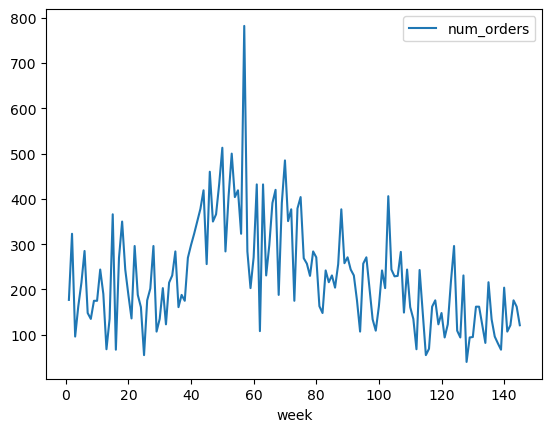

In [24]:
one = df[(df['center_id'] == 55) & (df['meal_id'] == 1885)].sort_values('week')
one.plot(x='week', y='num_orders')


## Pre Processing

In [25]:
# pre processing

df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,0.101517
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-0.007362
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,0.007361
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,0.224053
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-0.004124


In [26]:
# change center_id to centre_id
df = df.rename(columns={
    'center_id': 'centre_id',
    'center_type': 'centre_type',
})


In [27]:
df.head()

,id,week,centre_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,centre_type,op_area,category,cuisine,discount
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,0.101517
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-0.007362
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,0.007361
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,0.224053
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-0.004124


In [28]:
# order by week
df.sort_values(['centre_id','meal_id','week'])

,id,week,centre_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,centre_type,op_area,category,cuisine,discount
2370,1436842,1,10,1062,181.39,181.39,0,0,865,590,56,TYPE_B,6.3,Beverages,Italian,0.000000
5273,1205013,2,10,1062,183.36,182.36,0,0,782,590,56,TYPE_B,6.3,Beverages,Italian,-0.005484
8175,1447751,3,10,1062,184.36,182.36,0,0,851,590,56,TYPE_B,6.3,Beverages,Italian,-0.010967
11064,1014968,4,10,1062,182.36,183.36,0,0,1202,590,56,TYPE_B,6.3,Beverages,Italian,0.005454
13918,1003563,5,10,1062,183.39,181.39,0,0,958,590,56,TYPE_B,6.3,Beverages,Italian,-0.011026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345410,1255251,112,186,2956,583.03,581.03,0,0,82,649,34,TYPE_A,3.4,Fish,Continental,-0.003442
348601,1436164,113,186,2956,583.03,582.03,0,0,40,649,34,TYPE_A,3.4,Fish,Continental,-0.001718
351905,1000576,114,186,2956,583.03,581.03,0,0,27,649,34,TYPE_A,3.4,Fish,Continental,-0.003442
355206,1429037,115,186,2956,581.03,583.03,0,0,15,649,34,TYPE_A,3.4,Fish,Continental,0.003430


In [29]:
df.dtypes

id                         int64
week                       int64
centre_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
city_code                  int64
region_code                int64
centre_type               object
op_area                  float64
category                  object
cuisine                   object
discount                 float64
dtype: object

In [30]:
df = df.drop(columns='discount')

In [31]:
df.sort_values('num_orders', ascending=False).head(10)

,id,week,centre_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,centre_type,op_area,category,cuisine
14050,1452474,5,43,2290,159.08,311.43,1,1,24299,590,56,TYPE_A,5.1,Rice Bowl,Indian
19700,1300512,7,43,2290,159.08,311.43,1,1,15336,590,56,TYPE_A,5.1,Rice Bowl,Indian
16904,1087163,6,43,2290,156.20,310.43,0,1,14229,590,56,TYPE_A,5.1,Rice Bowl,Indian
13923,1470267,5,10,2290,162.99,309.43,1,0,13580,590,56,TYPE_B,6.3,Rice Bowl,Indian
413351,1346216,132,43,1971,204.70,324.04,1,1,13150,590,56,TYPE_A,5.1,Sandwich,Italian
12068,1352978,5,89,2290,162.02,309.43,1,1,12489,703,56,TYPE_A,4.8,Rice Bowl,Indian
90857,1238452,32,146,1754,194.03,268.69,1,1,12327,526,34,TYPE_B,5.0,Sandwich,Italian
12509,1091831,5,137,2290,159.11,307.49,1,1,12177,590,56,TYPE_A,4.4,Rice Bowl,Indian
12300,1002009,5,99,2290,162.02,309.49,1,1,12137,596,71,TYPE_A,4.5,Rice Bowl,Indian
85371,1398441,30,126,1754,144.56,279.36,1,1,11380,577,56,TYPE_A,2.7,Sandwich,Italian


## Feature Engineering
past weeks, average of recent weeks, discount, seasonality, feature encoding 


In [32]:
# Lag features (past weeks)
# lag_1 = what this meal sold last week.

df = df.sort_values(['centre_id','meal_id','week']).reset_index(drop=True)
df['lag_1'] = df.groupby(['centre_id','meal_id'])['num_orders'].shift(1)
# df[['centre_id','meal_id','week','num_orders','lag_1']].head(8)
# df['lag_1'].head(8)

for n in (1, 2, 3, 5):
    df[f'lag_{n}'] = df.groupby(['centre_id','meal_id'])['num_orders'].shift(n)

# df['lag_5'].head(8)

df[['week','num_orders','lag_1','lag_2','lag_3','lag_5']].head(8)

,week,num_orders,lag_1,lag_2,lag_3,lag_5
0,1,865,NaN,NaN,NaN,NaN
1,2,782,865.0,NaN,NaN,NaN
2,3,851,782.0,865.0,NaN,NaN
3,4,1202,851.0,782.0,865.0,NaN
4,5,958,1202.0,851.0,782.0,NaN
5,6,1094,958.0,1202.0,851.0,865.0
6,7,1513,1094.0,958.0,1202.0,782.0
7,8,1149,1513.0,1094.0,958.0,851.0


In [33]:
g = df.groupby(['centre_id','meal_id'])['num_orders']
df['roll_3']  = g.transform(lambda s: s.shift(1).rolling(3).mean())
df['roll_10'] = g.transform(lambda s: s.shift(1).rolling(10).mean())

df[['week','num_orders','lag_1','roll_3']].head(8)


,week,num_orders,lag_1,roll_3
0,1,865,NaN,NaN
1,2,782,865.0,NaN
2,3,851,782.0,NaN
3,4,1202,851.0,832.666667
4,5,958,1202.0,945.000000
5,6,1094,958.0,1003.666667
6,7,1513,1094.0,1084.666667
7,8,1149,1513.0,1188.333333


In [34]:
# ewma
# df['ewma'] = (df.groupby(['centre_id','meal_id'])['num_orders']
   #             .transform(lambda s: s.ewm(alpha=0.5, adjust=False).mean().shift(1)))


In [35]:
df['base_price'].min()

55.35

In [36]:
# Discount
# df['discount'] = (df['base_price'] - df['checkout_price']) / df['base_price']

base = df['base_price'].replace(0, np.nan)                     
df['discount'] = ((df['base_price'] - df['checkout_price']) / base).fillna(0)  


In [37]:
# Week-of-year (seasonality)
df['week_of_year'] = ((df['week'] - 1) % 52) + 1


In [38]:
df['base_price'].min()

55.35

In [39]:
df[['week','discount','week_of_year']].head(8)

,week,discount,week_of_year
0,1,0.000000,1
1,2,-0.005484,2
2,3,-0.010967,3
3,4,0.005454,4
4,5,-0.011026,5
5,6,0.116364,6
6,7,0.127106,7
7,8,0.122485,8


## Categorical encoding

In [40]:
for col in ['category', 'cuisine', 'centre_type']:
    df[col + '_code'] = df[col].astype('category').cat.codes


In [41]:
df.shape

(456548, 26)

## Dropna 
drop missing values

In [42]:
df = df.dropna(subset=['lag_1','lag_2','lag_3','lag_5','roll_3','roll_10'])


In [43]:
df.shape

(420705, 26)

In [44]:
df.isnull().sum()


id                       0
week                     0
centre_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
centre_type              0
op_area                  0
category                 0
cuisine                  0
lag_1                    0
lag_2                    0
lag_3                    0
lag_5                    0
roll_3                   0
roll_10                  0
discount                 0
week_of_year             0
category_code            0
cuisine_code             0
centre_type_code         0
dtype: int64

## Baseline + model comparison

In [45]:
# target = num_orders
# exluding 
drop_cols = ['num_orders', 'id', 'category', 'cuisine', 'centre_type']
feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols]
y = df['num_orders']


In [46]:
# Split data

# cutoff = df['week'].max() - 10    # hold out the last 10 weeks
# train = df[df['week'] <= cutoff]
# test  = df[df['week'] >  cutoff]

# X_train, y_train = train[feature_cols], train['num_orders']
# X_test,  y_test  = test[feature_cols],  test['num_orders']

# len(X_train), len(X_test)

feature_cols = [c for c in df.columns if c not in drop_cols]


N = df['week'].max()
train = df[df['week'] <= N - 20]                    
val   = df[(df['week'] > N - 20) & (df['week'] <= N - 10)] 
test  = df[df['week'] > N - 10]                      

X_train, y_train = train[feature_cols], train['num_orders']
X_val,   y_val   = val[feature_cols],   val['num_orders']
X_test,  y_test  = test[feature_cols],  test['num_orders']

print(f"train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")


train: 355168  val: 32746  test: 32791


In [ ]:
# df[feature_cols].corr()    


corr  = X_train.corr().abs()                              
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  
upper.stack().sort_values(ascending=False).head(15)         


checkout_price  base_price      0.953576
lag_2           roll_3          0.904987
roll_3          roll_10         0.877843
lag_1           roll_3          0.869715
lag_3           roll_3          0.868496
lag_5           roll_10         0.796605
lag_3           roll_10         0.785650
lag_2           roll_10         0.776775
lag_1           roll_10         0.757932
base_price      cuisine_code    0.716227
lag_1           lag_2           0.697015
lag_2           lag_3           0.695060
checkout_price  cuisine_code    0.682979
lag_5           roll_3          0.630373
lag_1           lag_3           0.601174
dtype: float64

In [48]:
# metrics

def metrics(y_true, y_pred):
    return {
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,   
        'MAE':  mean_absolute_error(y_true, y_pred),        
        'R2':   r2_score(y_true, y_pred),         
    }


In [49]:
# baseline: predict last week

baseline_pred = X_val['lag_1']     
metrics(y_val, baseline_pred)    



{'RMSE': 345.1522689244029,
 'MAE': 119.22885237891651,
 'R2': 0.32893127107470566}

In [50]:
# baseline: 3wk rolling avg

baseline_pred = X_val['roll_3']  
metrics(y_val, baseline_pred)     


{'RMSE': 343.7700205104733,
 'MAE': 121.69544371831674,
 'R2': 0.3342954329205914}

In [51]:
# baseline: 10wk rolling avg

baseline_pred = X_val['roll_10']   
metrics(y_val, baseline_pred)      


{'RMSE': 309.35723719053686,
 'MAE': 115.91678983692665,
 'R2': 0.4609040150839613}

In [52]:
# Models

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_jobs=-1, max_samples=0.5, random_state=42),
    'GradientBoosting': HistGradientBoostingRegressor(random_state=42),
}


results = {'Baseline (last week)': metrics(y_val, X_val['lag_1'])}  

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_val), 0, None)                   
    results[name] = metrics(y_val, pred)                       



pd.DataFrame(results).T



,RMSE,MAE,R2
Baseline (last week),345.152269,119.228852,0.328931
LinearRegression,263.173386,104.844254,0.609852
RandomForest,194.489970,79.922851,0.786921
GradientBoosting,193.362742,79.067146,0.789384


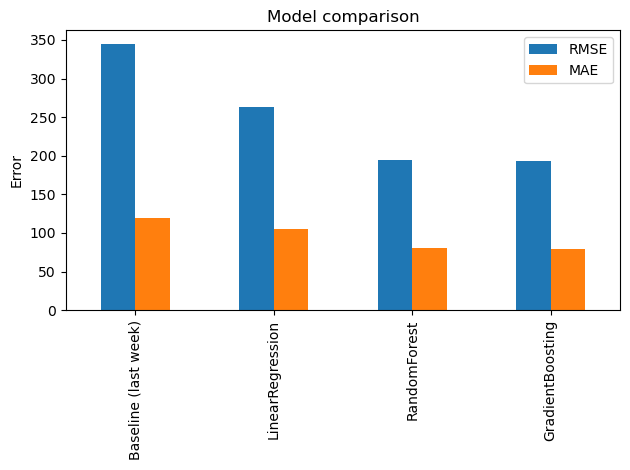

In [53]:
import matplotlib.pyplot as plt
results_df = pd.DataFrame(results).T    
results_df[["RMSE", "MAE"]].plot(kind="bar")

plt.title("Model comparison")
plt.ylabel("Error")    
plt.tight_layout()          
plt.show()


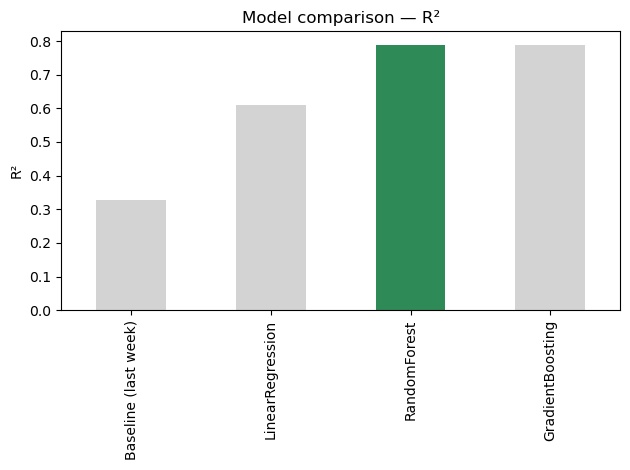

In [54]:
colors = ["seagreen" if m == "RandomForest" else "lightgray" for m in results_df.index]
results_df["R2"].plot(kind="bar", color=colors)

plt.title("Model comparison — R²")
plt.ylabel("R²")
plt.tight_layout()
plt.show()



In [55]:
def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

results = []   

for depth in [14, 18, 22]:
    for leaf in [1, 5, 20]:
        for feats in ['sqrt', 1.0]:
            m = RandomForestRegressor(
                n_estimators=200, max_depth=depth,
                min_samples_leaf=leaf, max_features=feats,
                max_samples=0.5, n_jobs=-1, random_state=42)
            m.fit(X_train, y_train)

            train_mae = mae(y_train, m.predict(X_train))  
            val_mae   = mae(y_val,   m.predict(X_val))    

            results.append({
                'max_depth': depth, 'min_samples_leaf': leaf,
                'max_features': feats,
                'train_mae': round(train_mae, 1),
                'val_mae':   round(val_mae, 1),
                'gap':       round(val_mae - train_mae, 1),  
            })

results_df = pd.DataFrame(results).sort_values('val_mae')
print(results_df.to_string(index=False))

 max_depth  min_samples_leaf max_features  train_mae  val_mae  gap
        18                 5         sqrt       63.0     78.1 15.1
        22                 5         sqrt       60.1     78.2 18.1
        18                 1         sqrt       56.1     78.3 22.3
        22                 1         sqrt       49.0     78.4 29.3
        22                 5          1.0       56.0     78.6 22.7
        18                 5          1.0       59.4     78.6 19.2
        14                 1         sqrt       65.4     78.6 13.1
        14                 5          1.0       65.3     78.7 13.4
        14                 5         sqrt       68.2     78.7 10.5
        22                20         sqrt       71.3     78.9  7.6
        18                20         sqrt       71.6     78.9  7.3
        14                20         sqrt       73.2     79.2  6.1
        14                 1          1.0       63.8     79.2 15.4
        18                 1          1.0       55.3     79.3 

In [56]:
# best config from the validation search 
best = results_df.iloc[0]
print("Best config:\n", best)

X_trv = pd.concat([X_train, X_val])
y_trv = pd.concat([y_train, y_val])

final = RandomForestRegressor(
    n_estimators=200,
    max_depth=None if best['max_depth'] == 'None' else int(best['max_depth']),
    min_samples_leaf=int(best['min_samples_leaf']),
    max_features=best['max_features'],
    max_samples=0.5, n_jobs=-1, random_state=42)
final.fit(X_trv, y_trv)

pred = final.predict(X_test).clip(0)
print({
    'RMSE': round(mean_squared_error(y_test, pred) ** 0.5, 2),
    'MAE':  round(mean_absolute_error(y_test, pred), 2),
    'R2':   round(r2_score(y_test, pred), 3),
})


Best config:
 max_depth             18
min_samples_leaf       5
max_features        sqrt
train_mae           63.0
val_mae             78.1
gap                 15.1
Name: 8, dtype: object
{'RMSE': 102.41, 'MAE': 61.36, 'R2': 0.863}


In [57]:
gb_results = []

for lr in [0.05, 0.1]:
    for iters in [300, 600]:
        for leaves in [31, 63]:
            m = HistGradientBoostingRegressor(
                learning_rate=lr, max_iter=iters, max_leaf_nodes=leaves,
                random_state=42)
            m.fit(X_train, y_train)

            train_mae = mae(y_train, m.predict(X_train))
            val_mae   = mae(y_val,   m.predict(X_val))

            gb_results.append({
                'learning_rate': lr, 'max_iter': iters, 'max_leaf_nodes': leaves,
                'train_mae': round(train_mae, 1),
                'val_mae':   round(val_mae, 1),
                'gap':       round(val_mae - train_mae, 1),
            })

gb_results_df = pd.DataFrame(gb_results).sort_values('val_mae')
print(gb_results_df.to_string(index=False))


 learning_rate  max_iter  max_leaf_nodes  train_mae  val_mae  gap
          0.05       600              63       60.0     76.4 16.4
          0.10       600              63       55.3     76.8 21.5
          0.10       300              63       60.2     77.0 16.8
          0.05       300              63       64.7     77.2 12.5
          0.05       600              31       65.2     77.6 12.5
          0.10       600              31       60.6     77.8 17.2
          0.10       300              31       65.4     77.9 12.5
          0.05       300              31       69.5     78.3  8.8


In [58]:
gb_best = gb_results_df.iloc[0]
final_gb = HistGradientBoostingRegressor(
    learning_rate=gb_best['learning_rate'],
    max_iter=int(gb_best['max_iter']),
    max_leaf_nodes=int(gb_best['max_leaf_nodes']),
    random_state=42)
final_gb.fit(X_trv, y_trv)                      
pred = np.clip(final_gb.predict(X_test), 0, None)
print("FINAL GBM test:", metrics(y_test, pred))


FINAL GBM test: {'RMSE': 121.60496360823622, 'MAE': 69.04276423016806, 'R2': 0.8067988553972903}


In [59]:
importances = pd.Series(final.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances


lag_1                    0.169056
roll_10                  0.161545
roll_3                   0.154503
emailer_for_promotion    0.082174
lag_3                    0.064699
lag_2                    0.062647
lag_5                    0.055455
discount                 0.052304
checkout_price           0.043103
homepage_featured        0.036928
category_code            0.025535
base_price               0.022431
cuisine_code             0.012932
week_of_year             0.012488
week                     0.011695
meal_id                  0.009104
op_area                  0.008571
centre_id                0.005980
city_code                0.004588
region_code              0.002491
centre_type_code         0.001772
dtype: float64

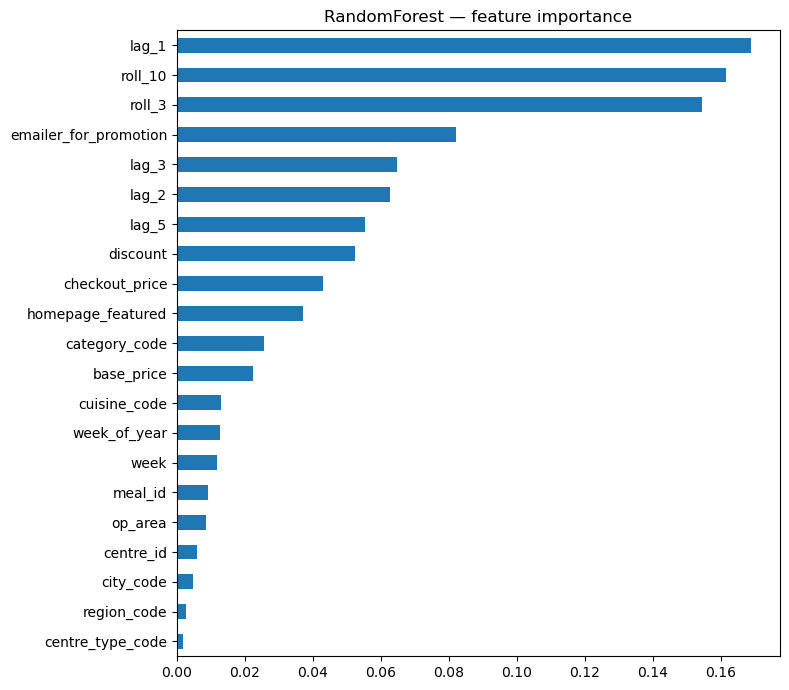

In [60]:
import matplotlib.pyplot as plt
importances.sort_values().plot.barh(figsize=(8, 7))
plt.title('RandomForest — feature importance')
plt.tight_layout()
plt.show()
